# Readme
### © Matteo Di Giovanni 2024

This code reads the .pkl output files of the analysis to visualize the SNR distributions and other things.

This program is free software; you can redistribute it and/or
modify it under the terms of the GNU General Public License
as published by the Free Software Foundation; either version 2
of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program; if not, write to the Free Software
Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301,
USA.

In [2]:
import numpy as np 
import pickle
import matplotlib.pyplot as plt

## Read the time to merger at 10 Hz and the time spent between 2 Hz and 10 Hz of the events

### BBH

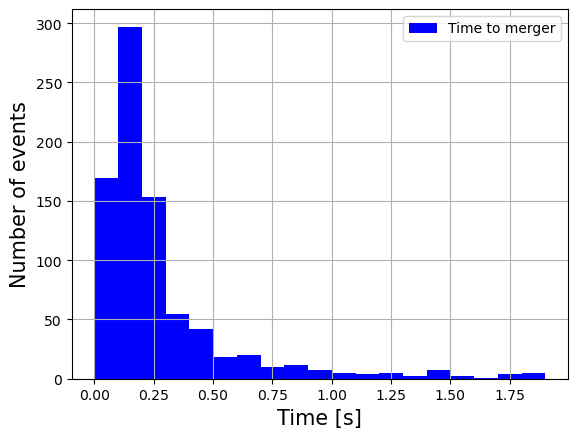

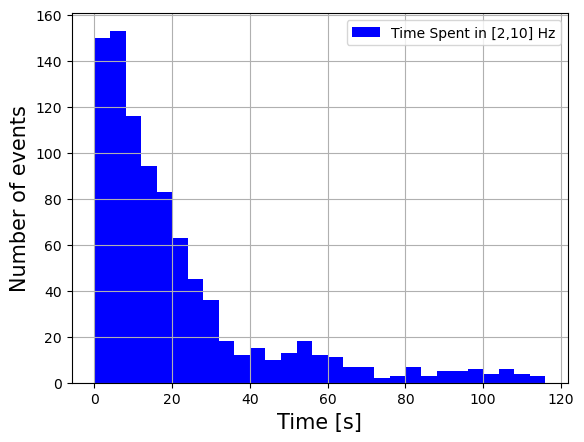

In [5]:
with open('../pkl/BBH_time_sum.pkl','rb') as f:
    
    times = pickle.load(f)
    
with open('../pkl/BBH_time_both.pkl','rb') as f:
    
    times2 = pickle.load(f)
    
with open('../pkl/BBH_time_at_least_one.pkl','rb') as f:
    
    times3 = pickle.load(f)
    
timesmerge=np.append(np.array(times[0],dtype=object),np.array(times2[0],dtype=object))
timesmerge=np.append(np.array(timesmerge,dtype=object),np.array(times3[0],dtype=object))

timestot=np.append(np.array(times[1],dtype=object),np.array(times2[1],dtype=object))
timestot=np.append(np.array(timestot,dtype=object),np.array(times3[1],dtype=object))

##### THE != 0 IS NEEDED BECAUSE FOR SOME EVENTS THE WAVEFORM GENERATION FAILS AND TIMESTOT IS SET TO 0 FOR CONVENTION

plt.hist(timesmerge[timestot != 0], color = 'blue', bins=np.arange(0, 2, 0.1), label = 'Time to merger')
plt.xlabel('Time [s]', size = 15)
plt.ylabel('Number of events', size = 15)
plt.legend()
plt.grid()
plt.show()

plt.hist(timestot[timestot != 0], color = 'blue', bins=np.arange(0, 120, 4), label = 'Time Spent in [2,10] Hz')
plt.xlabel('Time [s]', size = 15)
plt.ylabel('Number of events', size = 15)
plt.legend()
plt.grid()
plt.show()

### BNS

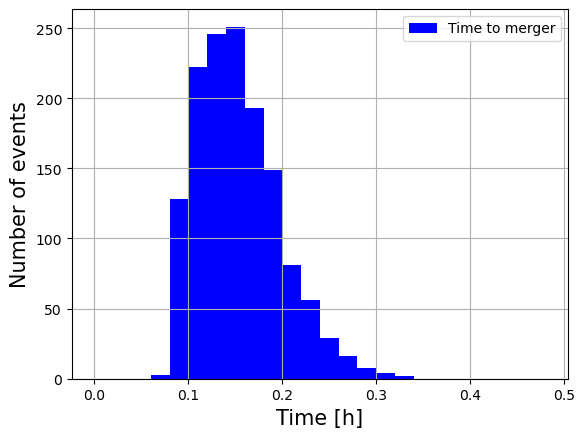

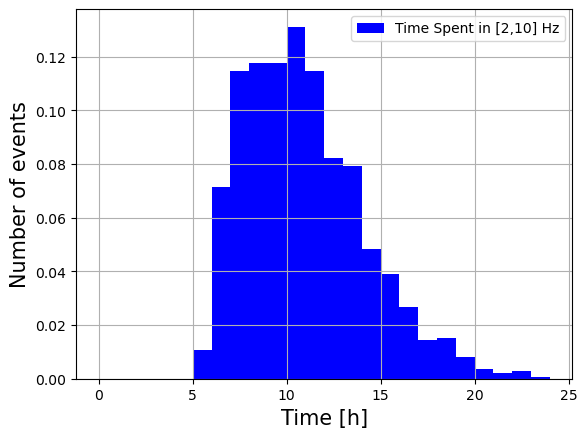

In [6]:
with open('../pkl/BNS_time_sum.pkl','rb') as f:
    
    times = pickle.load(f)
    
with open('../pkl/BNS_time_sum_HF.pkl','rb') as f:
    
    times2 = pickle.load(f)

##### THE != 0 IS NEEDED BECAUSE FOR SOME EVENTS THE WAVEFORM GENERATION FAILS AND TIMESTOT IS SET TO 0 FOR CONVENTION

plt.hist(np.array(times2[times2 != 0])/3600, bins=np.arange(0, 0.5, 0.02), color = 'blue', label = 'Time to merger')
plt.xlabel('Time [h]', size = 15)
plt.ylabel('Number of events', size = 15)
plt.legend()
plt.grid()
#plt.savefig('./figures/BBH_time_to_merger.jpg')
plt.show()
plt.clf()

plt.hist(np.array(times[times != 0])/3600, color = 'blue', bins=np.arange(0, 25, 1), label = 'Time Spent in [2,10] Hz', density = 'True')
plt.xlabel('Time [h]', size = 15)
plt.ylabel('Number of events', size = 15)
plt.legend()
plt.grid()
#plt.savefig('./figures/BBH_time_spent.jpg')

## Read the time to merger at detection for BNS events

### Sardinia

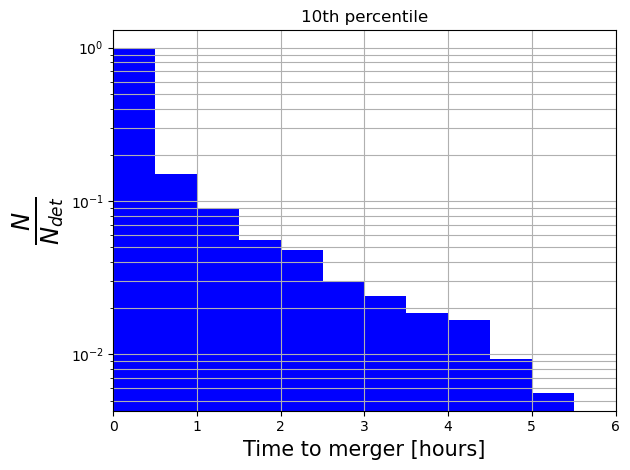

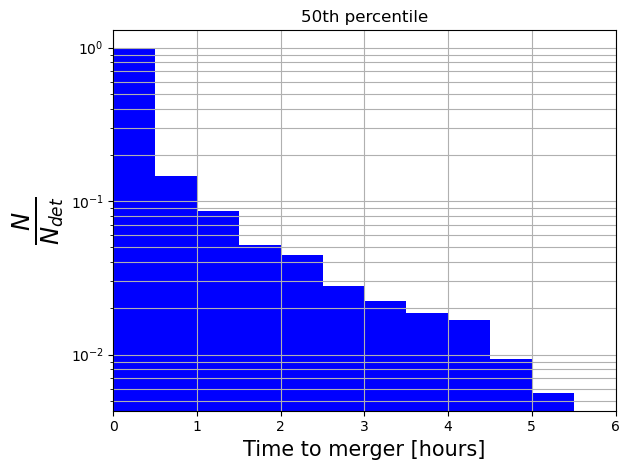

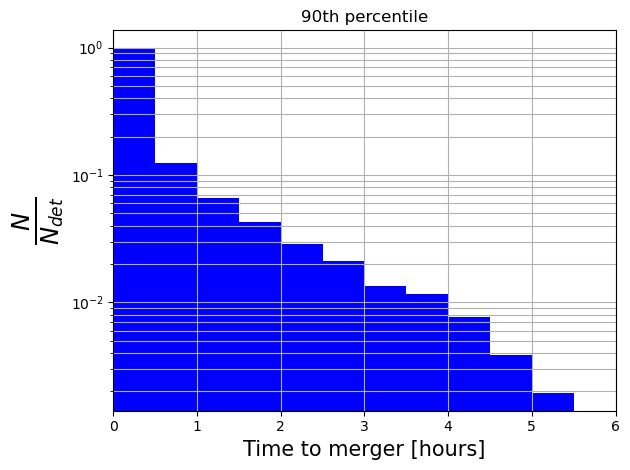

In [11]:
with open('../pkl/BNS_times_to_merge_SOS_BNS_sum_high_z.pkl','rb') as f:
    snr = pickle.load(f)   

    
#### THE TIMES FOR EACH PERCENTILE OF THE SEISMIC NOISE ARE SAVED CONSECTUVIELY ON THE SAME ARRAY.
#### THAT IS WHY WE HAVE TO READ VARIABLE THIS WAY

tmb = np.array(snr[2][0::4],dtype=object)
tm10 = np.array(snr[2][1::4],dtype=object)
tm50 = np.array(snr[2][2::4],dtype=object)
tm90 = np.array(snr[2][3::4],dtype=object)

#### WE PLOT ONLY TIMES > 0 BECAUSE EVENTS WHICH DO NOT REACH THE SNR THRESHOLD HAVE TIMES SET TO < 0 AS A CONVENTION

idx = np.where(tm10 > 0)[0]
plt.hist(np.unique(tm10)/3600, color = 'blue', alpha=1, bins=np.arange(0, 6, 0.5), cumulative = -1, density = 'True')
plt.title('10th percentile')
plt.xlabel('Time to merger [hours]', size = 15)
plt.ylabel(r'$\frac{N}{N_{det}}$', size = 25)
plt.yscale('log')
plt.xlim([0,6])
plt.grid(which= 'both')
plt.tight_layout()
plt.show()

idx = np.where(tm50 > 0)[0]
plt.hist(np.unique(tm50)/3600, color = 'blue', alpha=1, bins=np.arange(0, 6, 0.5), cumulative = -1, density = 'True')
plt.title('50th percentile')
plt.xlabel('Time to merger [hours]', size = 15)
plt.ylabel(r'$\frac{N}{N_{det}}$', size = 25)
plt.yscale('log')
plt.xlim([0,6])
plt.grid(which= 'both')
plt.tight_layout()
plt.show()

idx = np.where(tm90 > 0)[0]
plt.hist(np.unique(tm90)/3600, color = 'blue', alpha=1, bins=np.arange(0, 6, 0.5), cumulative = -1, density = 'True')
plt.title('90th percentile')
plt.xlabel('Time to merger [hours]', size = 15)
plt.ylabel(r'$\frac{N}{N_{det}}$', size = 25)
plt.yscale('log')
plt.xlim([0,6])
plt.grid(which= 'both')
plt.tight_layout()
plt.show()

### EMR

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1838,)
(1838,)
(929,)
(929,)
(528,)


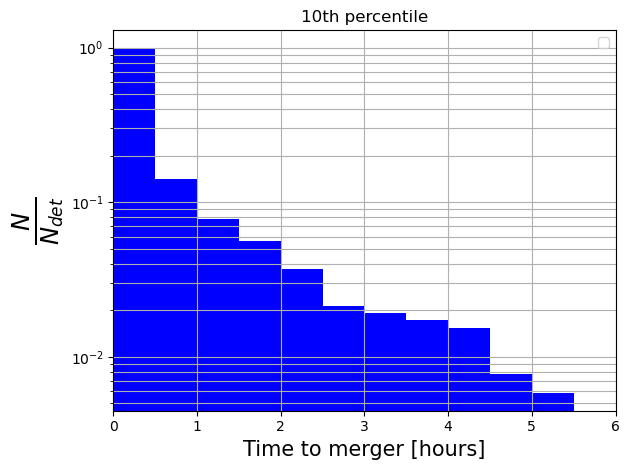

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(462,)


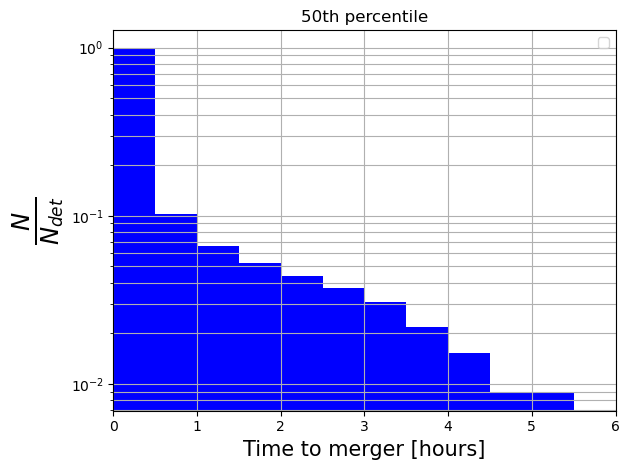

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(311,)


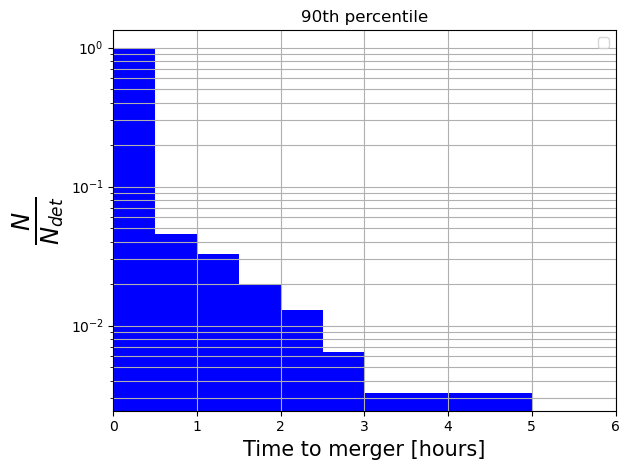

In [114]:
with open('/Users/matteodigiovanni/Documents/BNS_times_to_merge_TERZ_BNS_sum_high_z.pkl','rb') as f:
    snr = pickle.load(f)   

    
#### THE TIMES FOR EACH PERCENTILE OF THE SEISMIC NOISE ARE SAVED CONSECTUVIELY ON THE SAME ARRAY.
#### THAT IS WHY WE HAVE TO READ VARIABLE THIS WAY

tmb = np.array(snr[2][0::4],dtype=object)
tm10 = np.array(snr[2][1::4],dtype=object)
tm50 = np.array(snr[2][2::4],dtype=object)
tm90 = np.array(snr[2][3::4],dtype=object)

#### WE PLOT ONLY TIMES > 0 BECAUSE EVENTS WHICH DO NOT REACH THE SNR THRESHOLD HAVE TIMES SET TO < 0 AS A CONVENTION


idx = np.where(tm10 > 0)[0]
plt.hist(np.unique(tm10)/3600, color = 'blue', alpha=1, bins=np.arange(0, 6, 0.5), cumulative = -1, density = 'True')
plt.title('10th percentile')
plt.xlabel('Time to merger [hours]', size = 15)
plt.ylabel(r'$\frac{N}{N_{det}}$', size = 25)
plt.yscale('log')
plt.xlim([0,6])
plt.grid(which= 'both')
plt.tight_layout()
plt.savefig('./figures/time_to_BNS_distr_10th_SOS.jpg')
plt.show()

idx = np.where(tm50 > 0)[0]
plt.hist(np.unique(tm50)/3600, color = 'blue', alpha=1, bins=np.arange(0, 6, 0.5), cumulative = -1, density = 'True')
plt.title('50th percentile')
plt.xlabel('Time to merger [hours]', size = 15)
plt.ylabel(r'$\frac{N}{N_{det}}$', size = 25)
plt.yscale('log')
plt.xlim([0,6])
plt.grid(which= 'both')
plt.tight_layout()
plt.savefig('./figures/time_to_BNS_distr_50th_SOS.jpg')
plt.show()

idx = np.where(tm90 > 0)[0]
plt.hist(np.unique(tm90)/3600, color = 'blue', alpha=1, bins=np.arange(0, 6, 0.5), cumulative = -1, density = 'True')
plt.title('90th percentile')
plt.xlabel('Time to merger [hours]', size = 15)
plt.ylabel(r'$\frac{N}{N_{det}}$', size = 25)
plt.yscale('log')
plt.xlim([0,6])
plt.grid(which= 'both')
plt.tight_layout()
plt.savefig('./figures/time_to_BNS_distr_90th_SOS.jpg')
plt.show()

## READ THE SNR DISTRIBUTIONS

### BNS EMR

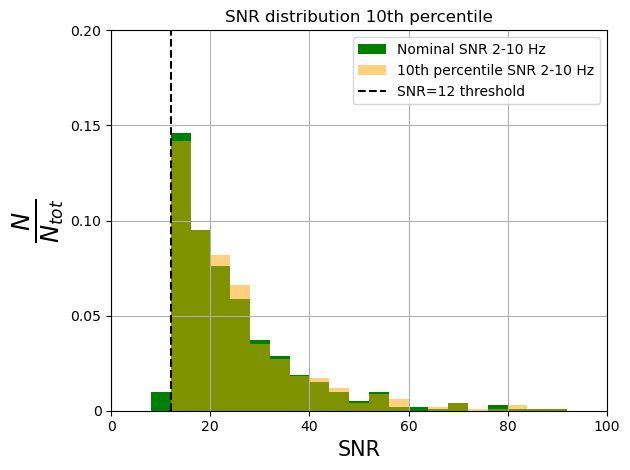

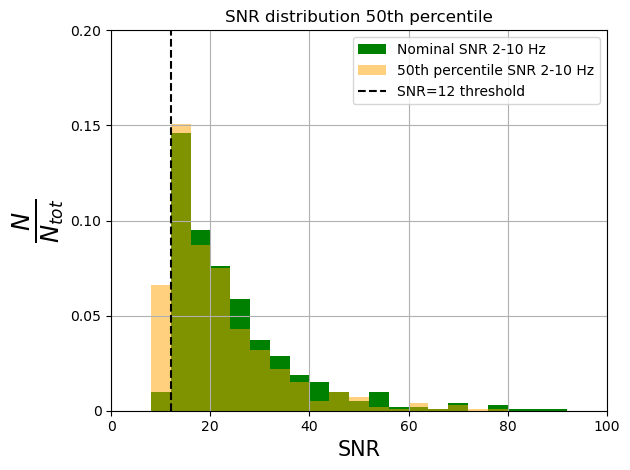

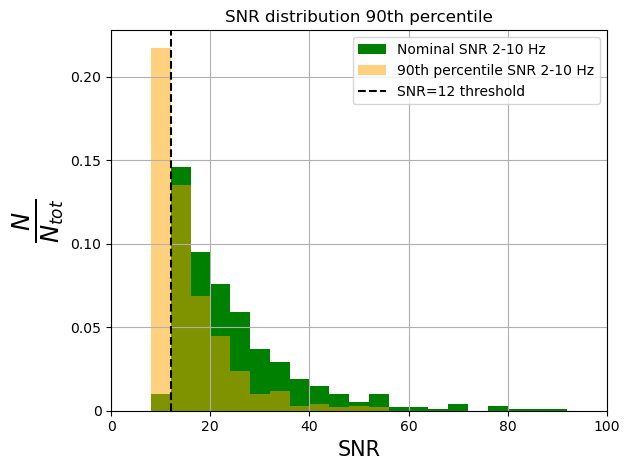

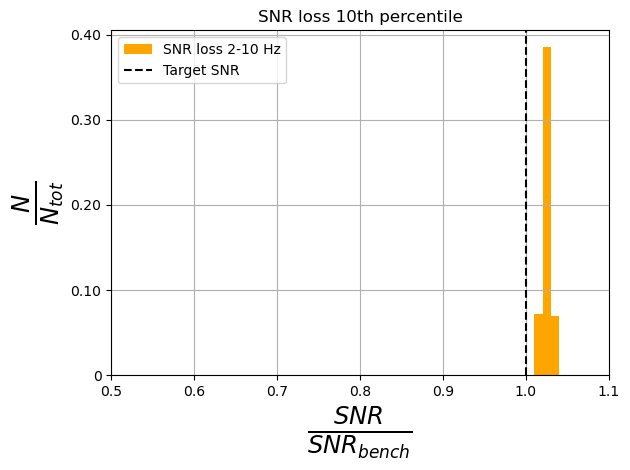

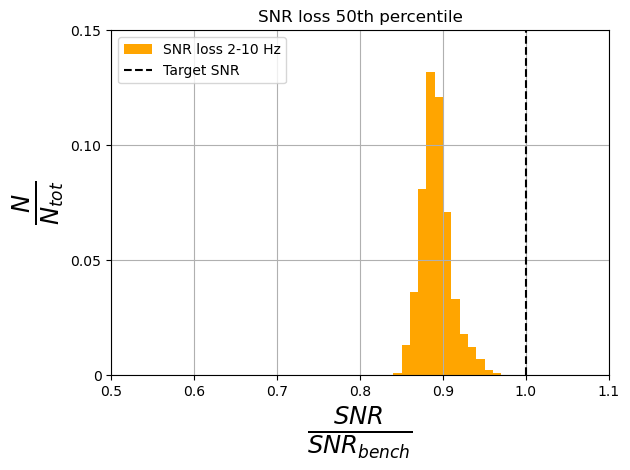

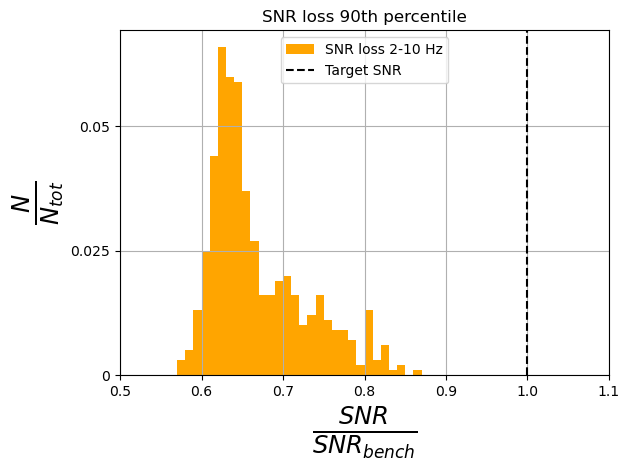

In [14]:
with open('../pkl/BNS_losses_TERZ_BNS_sum_high_z.pkl','rb') as f:
    snr = pickle.load(f)   

snr_bench=np.array(snr[0],dtype=object)
snr_10=np.array(snr[1],dtype=object)
snr_50=np.array(snr[2],dtype=object)
snr_90=np.array(snr[3],dtype=object)
idx = np.where(snr_10 >= 12)[0]
idx_b = np.where(snr_10 >= 12)[0]

plt.hist(snr_bench[idx_b], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_10[idx], color = 'orange', bins=np.arange(0, 140, 4), label = '10th percentile SNR 2-10 Hz', alpha=0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.yticks(ticks = [0, 50, 100, 150, 200], labels = ['0','0.05', '0.10', '0.15', '0.20'])
plt.xlim(0,100)
plt.title('SNR distribution 10th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.hist(snr_bench[idx_b], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_50[idx], color = 'orange', bins=np.arange(0, 140, 4), label = '50th percentile SNR 2-10 Hz', alpha = 0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.yticks(ticks = [0, 50, 100, 150, 200], labels = ['0','0.05', '0.10', '0.15', '0.20'])
plt.xlim(0,100)
plt.title('SNR distribution 50th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.hist(snr_bench[idx_b], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_90[idx], color = 'orange', bins=np.arange(0, 140, 4), label = '90th percentile SNR 2-10 Hz', alpha = 0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.yticks(ticks = [0, 50, 100, 150, 200], labels = ['0','0.05', '0.10', '0.15', '0.20'])
plt.xlim(0,100)
plt.title('SNR distribution 90th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.hist(snr_10[idx]/snr_bench[idx], color = 'orange', bins=np.arange(0.5, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha=1, density = False)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.yticks(ticks = [0, 100, 200, 300, 400], labels = ['0', '0.10', '0.20', '0.30', '0.40'])
plt.title('SNR loss 10th percentile')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.xlim(0.5,1.1)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.hist(snr_50[idx]/snr_bench[idx], color = 'orange', bins=np.arange(0.6, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1, density = False)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.yticks(ticks = [0, 50, 100, 150], labels = ['0','0.05', '0.10', '0.15'])
plt.title('SNR loss 50th percentile')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.xlim(0.5,1.1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.hist(snr_90[idx]/snr_bench[idx], color = 'orange', bins=np.arange(0.5, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1, density = False)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.yticks(ticks = [0, 25, 50], labels = ['0','0.025','0.05'])
plt.title('SNR loss 90th percentile')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.xlim(0.5,1.1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### BNS Sardinia

[16.43251369337297 9.455683661234998 9.097802558900845 ...
 8.533523237268817 8.300064670774445 8.60801571909595]
[12.71466201558246 9.291466115799459 9.027858565177485 ...
 8.894077433931152 8.212453718455599 8.6013958681931]
[17.020642993146392 9.434750475929285 9.065475965696805 ...
 8.511948423354527 8.25734499034472 8.58756850936433]


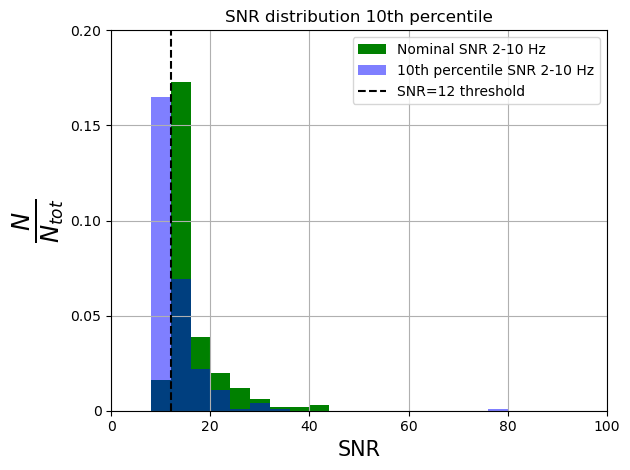

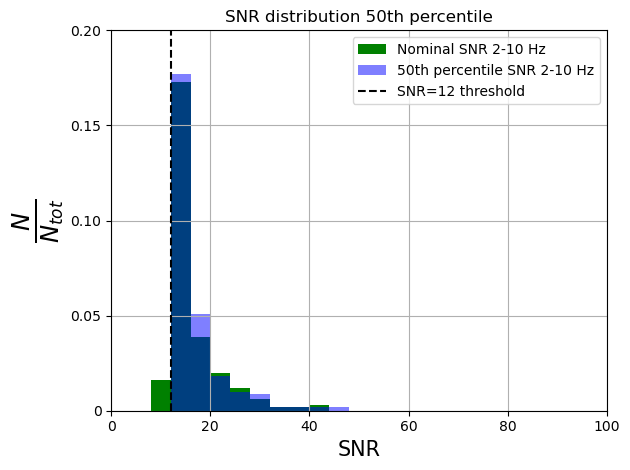

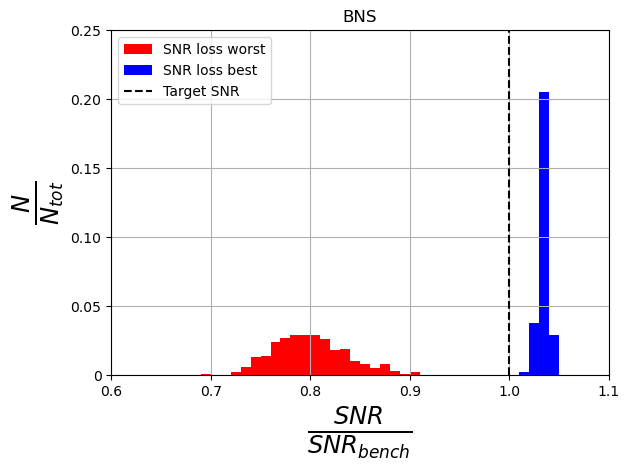

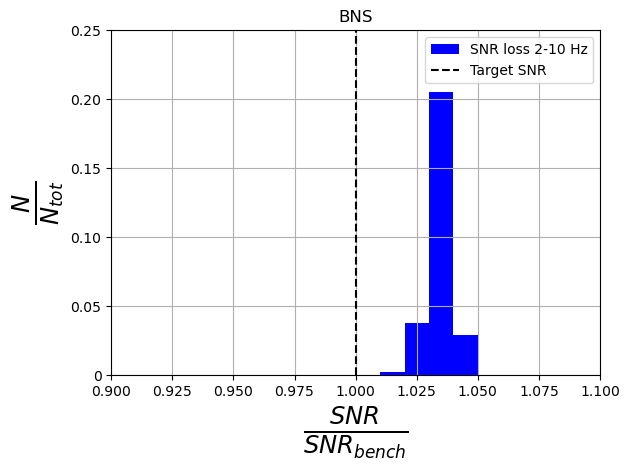

1.0345951514126424
0.7999575050960657
2630
2614
2779


In [3]:
with open('../pkl/BNS_losses_SOS_BNS_sum_high_z_worstbest.pkl','rb') as f:
    snr = pickle.load(f)   

snr_bench=np.array(snr[0],dtype=object)
snr_10=np.array(snr[1],dtype=object)
snr_50=np.array(snr[2],dtype=object)
#snr_90=np.array(snr[3],dtype=object)
idx = np.where(snr_50 >= 12)[0]
idx_b = np.where(snr_50 >= 12)[0]

print(snr_bench)
print(snr_10)
print(snr_50)

plt.hist(snr_bench[idx_b], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_10[idx], color = 'blue', bins=np.arange(0, 140, 4), label = '10th percentile SNR 2-10 Hz', alpha=0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.yticks(ticks = [0, 50, 100, 150, 200], labels = ['0','0.05', '0.10', '0.15', '0.20'])
plt.xlim(0,100)
plt.title('SNR distribution 10th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.hist(snr_bench[idx_b], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_50[idx], color = 'blue', bins=np.arange(0, 140, 4), label = '50th percentile SNR 2-10 Hz', alpha = 0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.yticks(ticks = [0, 50, 100, 150, 200], labels = ['0','0.05', '0.10', '0.15', '0.20'])
plt.xlim(0,100)
plt.title('SNR distribution 50th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#plt.hist(snr_bench[idx_b], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
#plt.hist(snr_90[idx], color = 'blue', bins=np.arange(0, 140, 4), label = '90th percentile SNR 2-10 Hz', alpha = 0.5)
#plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
#plt.yticks(ticks = [0, 50, 100, 150, 200], labels = ['0','0.05', '0.10', '0.15', '0.20'])
#plt.xlim(0,100)
#plt.title('SNR distribution 90th percentile')
#plt.xlabel('SNR', size = 15)
#plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
#plt.legend()
#plt.grid()
#plt.tight_layout()
#plt.show()

plt.hist(snr_10[idx]/snr_bench[idx], color = 'red',bins=np.arange(0.6, 1.1, 0.01), label = 'SNR loss worst', density = False,alpha = 1)
plt.hist(snr_50[idx]/snr_bench[idx], color = 'blue', bins=np.arange(0.6, 1.1, 0.01), label = 'SNR loss best',  density = False,alpha = 1)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
#plt.yticks(ticks = [0, 25, 50, 75,100], labels = ['0', '0.025','0.05','0.075','0.1'])
plt.yticks(ticks = [0, 50, 100, 150, 200, 250, 300, 400], labels = ['0','0.05', '0.10','0.15', '0.20','0.25', '0.30', '0.40'])
plt.title('BNS')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.xlim(0.6,1.1)
plt.ylim(0,250)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('/users/matteodigiovanni/Downloads/BNS_all.png')
plt.show()

plt.hist(snr_50[idx]/snr_bench[idx], color = 'blue', bins=np.arange(0.9, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1, density = False)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.yticks(ticks = [0, 50, 100, 150, 200, 250, 300, 400], labels = ['0','0.05', '0.10','0.15', '0.20','0.25', '0.30', '0.40'])
plt.title('BNS')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.xlim(0.9,1.1)
plt.ylim(0,250)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/users/matteodigiovanni/Downloads/BNS_best.png')
plt.show()

#plt.hist(snr_90[idx]/snr_bench[idx], color = 'blue', bins=np.arange(0.9, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1, density = False)
#plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
#plt.yticks(ticks = [0, 25, 50], labels = ['0','0.025','0.05'])
#plt.title('SNR loss 90th percentile')
#plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
#plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
#plt.xlim(0.9,1.1)
#plt.legend()
#plt.grid(True)
#plt.tight_layout()
#plt.show()

print(np.mean(snr_50[idx]/snr_bench[idx]))
print(np.mean(snr_10[idx]/snr_bench[idx]))
print(len(np.where(snr_bench < 12)[0]))
print(len(np.where(snr_50 < 12)[0]))
print(len(np.where(snr_10 < 12)[0]))

### BBH Sardinia

[24.17595954  8.72345286 11.66897575 ... 27.68430523 24.68365235
 37.61700187]
[24.67248732  8.73845448 11.83552053 ... 28.23462527 24.88889963
 38.19285854]
[24.80262632  8.76180782 11.88155618 ... 28.35358852 24.7210067
 38.40449434]


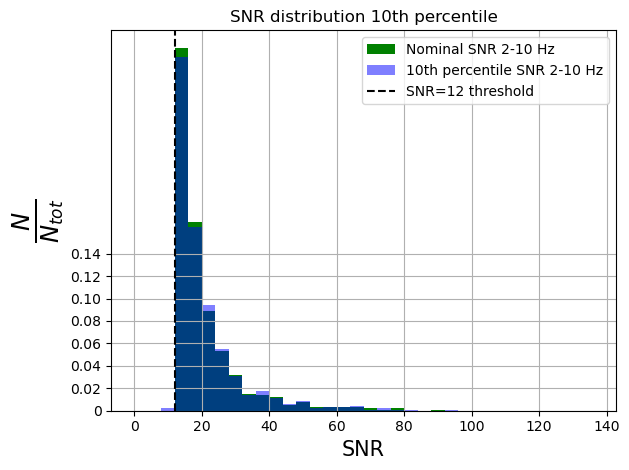

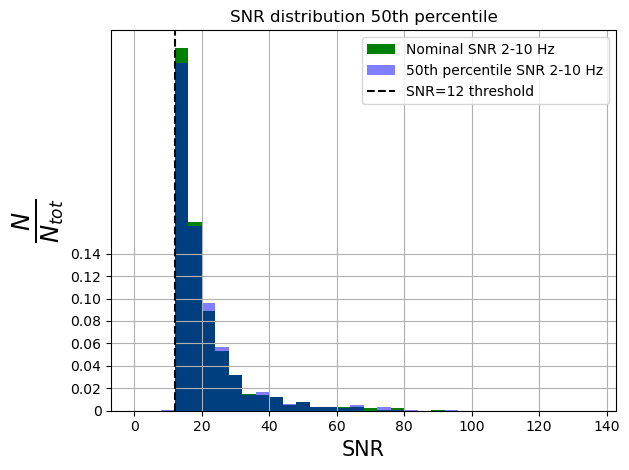

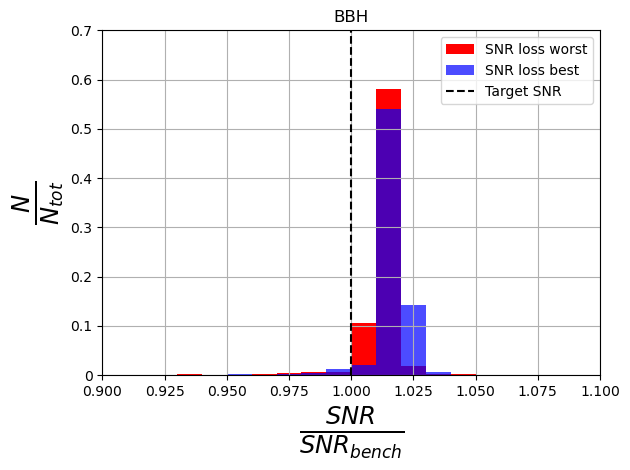

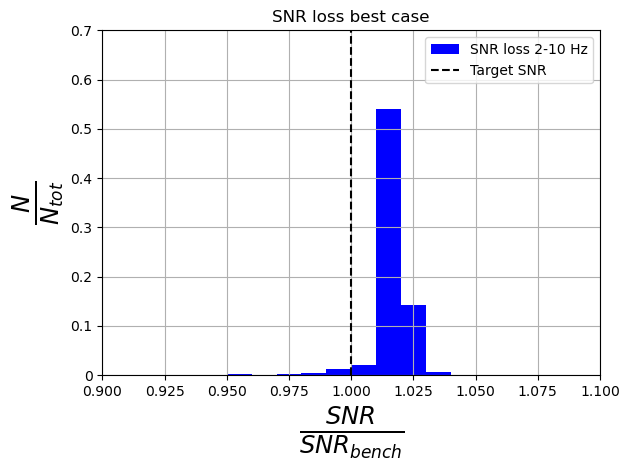

1.0167896396977112
1.0118017188243158
1154
1130
1135


In [2]:
with open('../pkl/SNR_losses_SOS_BBH_at_least_one.pkl','rb') as f:
    
    snr = pickle.load(f)
    
with open('../pkl/SNR_losses_SOS_BBH_both.pkl','rb') as f:
    
    snr2 = pickle.load(f)
    
with open('../pkl/BBH_losses_SOS_BBH_sum_high_z.pkl','rb') as f:
    
    snr3 = pickle.load(f)
    

#snr_bench=np.append(np.array(snr[0],dtype=object),np.array(snr2[0],dtype=object))
#snr_bench=np.append(np.array(snr_bench,dtype=object),np.array(snr3[0],dtype=object))

snr_bench = np.array(snr3[0])
snr_10 = np.array(snr3[1])
snr_50 = np.array(snr3[2])

print(np.array(snr_bench))
print(np.array(snr_10))
print(np.array(snr_50))

#snr_10=np.append(np.array(snr[1],dtype=object),np.array(snr2[1],dtype=object))
#snr_10=np.append(np.array(snr_10,dtype=object),np.array(snr3[1],dtype=object))
#
#snr_50=np.append(np.array(snr[2],dtype=object),np.array(snr2[2],dtype=object))
#snr_50=np.append(np.array(snr_50,dtype=object),np.array(snr3[2],dtype=object))
#
#snr_90=np.append(np.array(snr[3],dtype=object),np.array(snr2[3],dtype=object))
#snr_90=np.append(np.array(snr_90,dtype=object),np.array(snr3[3],dtype=object))

idx = np.where(snr_bench >= 12)[0]

plt.hist(snr_bench[idx], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_10[idx], color = 'blue', bins=np.arange(0, 140, 4), label = '10th percentile SNR 2-10 Hz', alpha=0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.yticks(ticks = [0, 20, 40, 60, 80, 100, 120, 140], labels = ['0','0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
plt.title('SNR distribution 10th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.hist(snr_bench[idx], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_50[idx], color = 'blue', bins=np.arange(0, 140, 4), label = '50th percentile SNR 2-10 Hz', alpha = 0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.yticks(ticks = [0, 20, 40, 60, 80, 100, 120, 140], labels = ['0','0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
plt.title('SNR distribution 50th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#plt.hist(snr_bench[idx], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
#plt.hist(snr_90[idx], color = 'blue', bins=np.arange(0, 140, 4), label = '90th percentile SNR 2-10 Hz', alpha = 0.5)
#plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
#plt.yticks(ticks = [0, 20, 40, 60, 80, 100, 120, 140], labels = ['0','0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
#plt.title('SNR distribution 90th percentile')
#plt.xlabel('SNR', size = 15)
#plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
#plt.tight_layout()
#plt.legend()
#plt.grid()
#plt.show()

plt.hist(snr_10[idx]/snr_bench[idx], color = 'red', bins=np.arange(0.6, 1.1, 0.01), label = 'SNR loss worst', alpha=1)
plt.hist(snr_50[idx]/snr_bench[idx], color = 'blue', bins=np.arange(0.9, 1.1, 0.01), label = 'SNR loss best', alpha = 0.7)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.title('BBH')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.yticks(ticks = [0, 100, 200, 300, 400, 500, 600, 700], labels = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7'])
#plt.yticks(ticks = [0, 25, 50, 75,100], labels = ['0', '0.025','0.05','0.075','0.1'])
plt.xlim(0.9,1.1)
#plt.ylim(top = 500)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('/users/matteodigiovanni/Downloads/BBH_all_norm.png')
plt.show()


plt.hist(snr_50[idx]/snr_bench[idx], color = 'blue', bins=np.arange(0.9, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.title('SNR loss best case')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.yticks(ticks = [0, 100, 200, 300, 400, 500, 600, 700], labels = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7'])
plt.xlim(0.9,1.1)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('/users/matteodigiovanni/Downloads/BBH_worst.png')
plt.show()


#plt.hist(snr_90[idx]/snr_bench[idx], color = 'blue', bins=np.arange(0.9, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1)
#plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
#plt.title('SNR loss 90th percentile')
#plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
#plt.ylabel('Number of events', size = 15)
#plt.yticks(ticks = [0, 100, 200, 300, 400, 500, 600, 700], labels = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7'])
#plt.xlim(0.9,1.1)
#plt.legend()
#plt.grid(True)
#plt.tight_layout()
#plt.show()

print(np.mean(snr_50[idx]/snr_bench[idx]))
print(np.mean(snr_10[idx]/snr_bench[idx]))
print(len(np.where(snr_bench < 12)[0]))
print(len(np.where(snr_50 < 12)[0]))
print(len(np.where(snr_10 < 12)[0]))

### BBH EMR

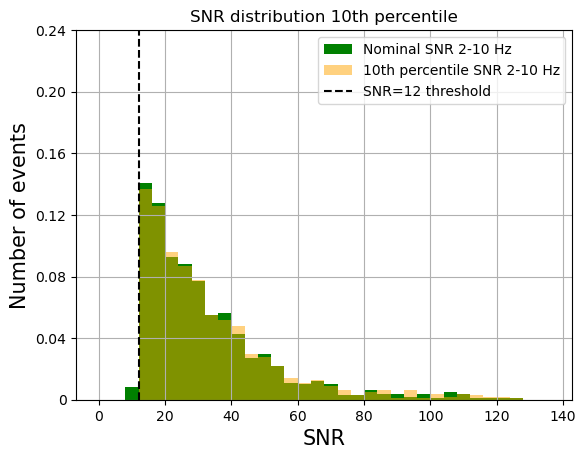

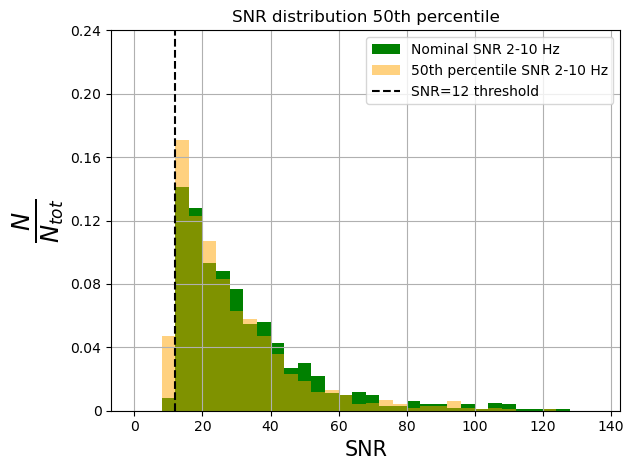

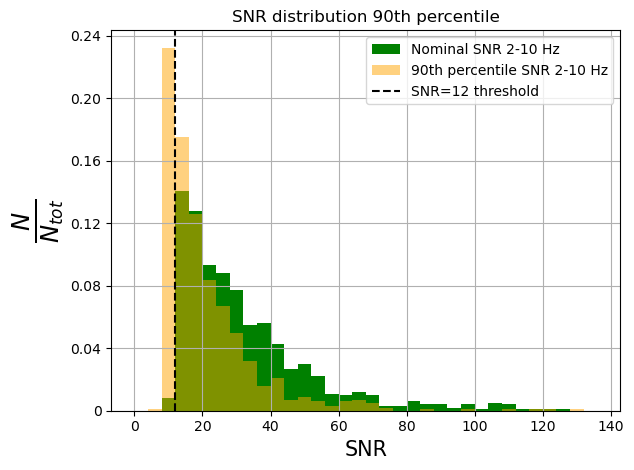

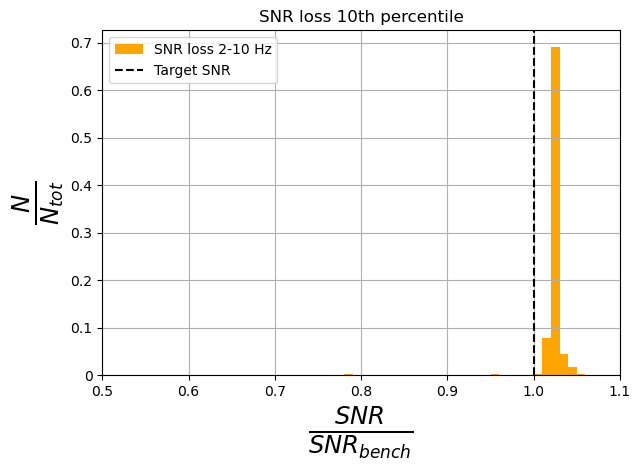

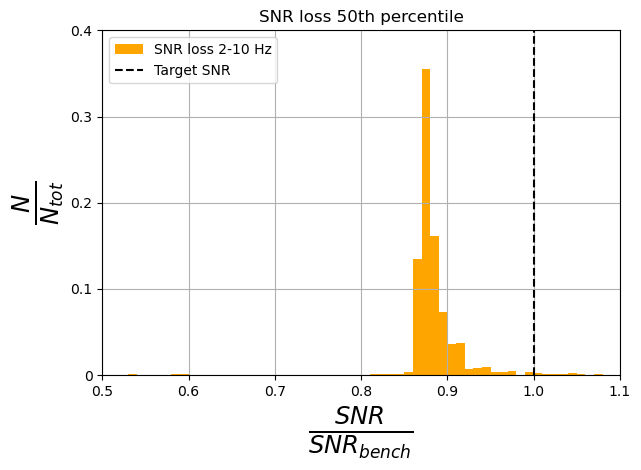

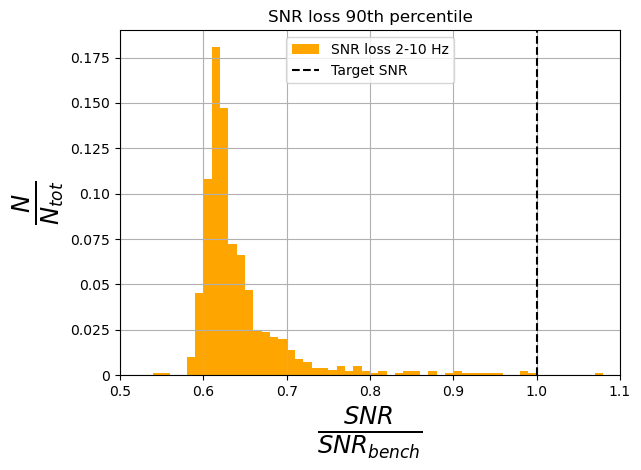

In [19]:
with open('../pkl/SNR_losses_TERZ_BBH_at_least_one.pkl','rb') as f:
    
    snr = pickle.load(f)
    
with open('../pkl/SNR_losses_TERZ_BBH_both.pkl','rb') as f:
    
    snr2 = pickle.load(f)
    
with open('../pkl/SNR_losses_TERZ_BBH_sum.pkl','rb') as f:
    
    snr3 = pickle.load(f)
    

snr_bench=np.append(np.array(snr[0],dtype=object),np.array(snr2[0],dtype=object))
snr_bench=np.append(np.array(snr_bench,dtype=object),np.array(snr3[0],dtype=object))

snr_10=np.append(np.array(snr[1],dtype=object),np.array(snr2[1],dtype=object))
snr_10=np.append(np.array(snr_10,dtype=object),np.array(snr3[1],dtype=object))

snr_50=np.append(np.array(snr[2],dtype=object),np.array(snr2[2],dtype=object))
snr_50=np.append(np.array(snr_50,dtype=object),np.array(snr3[2],dtype=object))

snr_90=np.append(np.array(snr[3],dtype=object),np.array(snr2[3],dtype=object))
snr_90=np.append(np.array(snr_90,dtype=object),np.array(snr3[3],dtype=object))

idx = np.where(snr_10 >= 12)[0]

plt.hist(snr_bench[idx], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_10[idx], color = 'orange', bins=np.arange(0, 140, 4), label = '10th percentile SNR 2-10 Hz', alpha=0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.title('SNR distribution 10th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel('Number of events', size = 15)
plt.yticks(ticks = [0, 40, 80, 120, 160, 200, 240], labels = ['0', '0.04', '0.08', '0.12', '0.16', '0.20','0.24'])
plt.legend()
plt.grid()
plt.show()

plt.hist(snr_bench[idx], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_50[idx], color = 'orange', bins=np.arange(0, 140, 4), label = '50th percentile SNR 2-10 Hz', alpha = 0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.title('SNR distribution 50th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.tight_layout()
plt.yticks(ticks = [0, 40, 80, 120, 160, 200, 240], labels = ['0', '0.04', '0.08', '0.12', '0.16', '0.20','0.24'])
plt.legend()
plt.grid()
plt.show()

plt.hist(snr_bench[idx], color = 'green', bins=np.arange(0, 140, 4), label = 'Nominal SNR 2-10 Hz')
plt.hist(snr_90[idx], color = 'orange', bins=np.arange(0, 140, 4), label = '90th percentile SNR 2-10 Hz', alpha = 0.5)
plt.axvline(x=12, color = 'k', label = 'SNR=12 threshold', linestyle = 'dashed')
plt.title('SNR distribution 90th percentile')
plt.xlabel('SNR', size = 15)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.tight_layout()
plt.yticks(ticks = [0, 40, 80, 120, 160, 200, 240], labels = ['0', '0.04', '0.08', '0.12', '0.16', '0.20','0.24'])
plt.legend()
plt.grid()
plt.show()

plt.hist(snr_10[idx]/snr_bench[idx], color = 'orange', bins=np.arange(0.5, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha=1)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.yticks(ticks = [0, 100, 200, 300, 400, 500, 600, 700], labels = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7'])
plt.title('SNR loss 10th percentile')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.tight_layout()
plt.xlim(0.5,1.1)
plt.legend()
plt.grid()
plt.show()

plt.hist(snr_50[idx]/snr_bench[idx], color = 'orange', bins=np.arange(0.5, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.yticks(ticks = [0, 100, 200, 300, 400], labels = ['0', '0.1', '0.2', '0.3', '0.4'])
plt.title('SNR loss 50th percentile')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.tight_layout()
plt.xlim(0.5,1.1)
plt.legend()
plt.grid()
plt.show()

plt.hist(snr_90[idx]/snr_bench[idx], color = 'orange', bins=np.arange(0.5, 1.1, 0.01), label = 'SNR loss 2-10 Hz', alpha = 1)
plt.axvline(x=1, color = 'k', label = 'Target SNR', linestyle = 'dashed')
plt.yticks(ticks = [0, 25, 50, 75, 100, 125, 150, 175], labels = ['0','0.025','0.05', '0.075', '0.10', '0.125', '0.150', '0.175'])
plt.title('SNR loss 90th percentile')
plt.xlabel(r'$\frac{SNR}{SNR_{bench}}$', size = 25)
plt.ylabel(r'$\frac{N}{N_{tot}}$', size = 25)
plt.tight_layout()
plt.xlim(0.5,1.1)
plt.legend()
plt.grid()
plt.show()

# SANDBOX

Examples of event and noise generation already contained in the main code for the analysis

In [3]:
def noise_from_sqrt_psd(old_freq, sqrt_psd, fs, dur, seed):    #dur=sample   sample=fs*dur

    frequencies = np.linspace(0, fs // 2, dur * fs // 2 + 1)

    norm = 0.5 * dur ** 0.5

    # Fourier-amplitudes of white noise
    _rng_state = np.random.RandomState(seed=seed)
    re = _rng_state.normal(0, norm, len(frequencies))
    im = _rng_state.normal(0, norm, len(frequencies))
    wtilde = re + 1j * im

    rpsd = np.interp(frequencies, old_freq, sqrt_psd, left=0, right=0)

    ctilde = wtilde * rpsd

    # set DC = 0
    ctilde[0] = 0
    # print(frequencies)
    time_series = np.fft.irfft(ctilde) * fs

    return time_series
    
def read_txt(filename):
    
    with open(filename) as inf:
        reader = csv.reader(inf, delimiter=" ")
        col_1 = list(zip(*reader))[0]
    col_1 = np.asarray(col_1, dtype=np.float32)
    
    with open(filename) as inf:
        reader = csv.reader(inf, delimiter=" ")
        col_2 = list(zip(*reader))[1]
    col_2 = np.asarray(col_2, dtype=np.float32)

    return col_1, col_2

def wf_timeseries(gps_start, quad, time, fs):
        
    ## GENERATE WF TIMESERIES

    signal_ts    = TimeSeries(quad, sample_rate = fs, t0 = gps_start, times = time)
    #signal_ts    = signal_ts.resample(rate = 4096) # Sampling rate of waveform and noise must be the same
    signal_ts    = signal_ts.taper()
    signal_ts.t0 = gps_start

    return signal_ts

def welch_method(time_strain, fs, seg_len_secs):
    
    dt              = 1/fs                   # dt time interval
    N               = len(time_strain)       # dur*fs
    #seg_len_secs    = 600                    # [s] divido in slot di 128s
    seg_len_samps   = int(seg_len_secs//dt)  # [sample] dei segmenti da 128s
    taperWindow     = np.hanning(seg_len_samps)

    fq1, Pxx_spec1 = scipy.signal.welch(time_strain, fs=fs, window=taperWindow, nperseg= seg_len_samps, scaling = 'density', return_onesided = True)
    fq2, Pxx_spec2 = scipy.signal.welch(time_strain, fs=fs, window=taperWindow, nperseg= seg_len_samps, scaling = 'density', return_onesided = False)
    
    #print(Pxx_spec1)
    
    asd1           = np.sqrt(Pxx_spec1)
    asd2           = np.sqrt(Pxx_spec2)
    
    
    return fq1, asd1, fq2, asd2

def inject(ts, gps_start, filename, time, fs):
    
    signal_ts = wf_timeseries(filename.start_time, filename, time, fs)
    ts        = TimeSeries(ts, t0 = gps_start, sample_rate = fs)
    data      = ts.inject(signal_ts)  ## <------------- INJECT SIGNAL IN SIMULATED NOISE
    
    return data
    
def unifom_dist(N, xmin, xmax):  # generate uniform distribution
    distr_gps_times = []
    for _ in range(N):
        x = random.uniform(xmin, xmax)
        distr_gps_times.append(x)
    return distr_gps_times

def normalize_to_01(vector):   # Normalize in [0, 1]
    min_val = np.min(vector)
    max_val = np.max(vector)
    normalized_vector = (vector - min_val) / (max_val - min_val)
    return normalized_vector

In [1]:
import warnings
import numpy as np
import csv
import scipy
import h5py
import random

import matplotlib.pyplot as plt
import pickle
from pycbc.detector import add_detector_on_earth
from pycbc.waveform import get_td_waveform, get_fd_waveform
from pycbc.detector import Detector
from lal import LIGOTimeGPS
from gwpy.timeseries import TimeSeries
from gwpy.frequencyseries import FrequencySeries
from pycbc.pnutils import get_inspiral_tf
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation
from astropy.units import Quantity
from datetime import datetime
from gwpy.time import from_gps
from pycbc import waveform
from pycbc.conversions import tau3_from_mass1_mass2, tau0_from_mchirp, mass1_from_mchirp_q, mchirp_from_mass1_mass2
from scipy.signal import savgol_filter
from pycbc.filter import sigma
from gwpy.time import tconvert, to_gps
warnings.filterwarnings("ignore")

/Users/matteodigiovanni/anaconda3/envs/pycbc/lib/python3.9/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [4]:
catalogName = './catalogs/18321_1yrCatalogBBH.h5'   #BBH
catalogName = './catalogs/18321_1yrCatalogBNS.h5'    #BNS

events={}

with h5py.File(catalogName, 'r') as f:
    for key in f.keys():
        events[key] = np.array(f[key])

N = len(events['tGPS'])  # Numerber of values to generate
gps_min = int(to_gps('Jan 01 2030 00:00:00.000'))
gps_max = int(to_gps('Jan 01 2031 00:00:00.000'))

distr_gps_times = unifom_dist(N, gps_min, gps_max)
events['tGPS']  = np.array(distr_gps_times)        # new GPS times in 1yr
events['tcoal'] = normalize_to_01(events['tGPS'])

case           = 'TERZ'                     # SOS, TERZ
config         = 'TRIANGLE'                # TRIANGLE, 2L
plots          = False
apx            = 'TaylorT2' #'IMRPhenomD' 'IMRPhenomPv2_NRTidalv2'
fs             = 4096
f_lower        = 10
f_cut          = 10
f_start        = 2
net            = 0
nominal_SNR    = []
deci_SNR       = []
cinqui_SNR     = []
nova_SNR       = []
deci_loss      = []
cinqui_loss    = []
nova_loss      = []
file_list      = ['./sens_curves/ET_ALL_NB.txt', './sens_curves/ET_TERZ_10th_perc_1year.txt', './sens_curves/ET_TERZ_50th_perc_1year.txt', './sens_curves/ET_TERZ_90th_perc_1year.txt']
index          = 0

i = 0

time_to_merge = []
time_tot = []

In [4]:
for sel,m in enumerate(events['m1_source']):
    
    

    #if m >= 100 and events['m2_source'][sel] >= 100:
    if (events['z'][sel]) <= 0.25:
        #if events['z'][sel] >= 0.1 and events['z'][sel] < 0.2:
        
        
        print(i)
        
        print(m,events['m2_source'][sel], events['tGPS'][sel], events['z'][sel], events['psi'][sel],events['dec'][sel],events['ra'][sel],events['dL'][sel])

        end_time       = events['tGPS'][sel]                                  #1395411177 #1192529720
        declination    = events['dec'][sel]                                   #-20*np.pi/180#-70*np.pi/180 #0.65
        right_ascension= events['ra'][sel]                                    #15*np.pi/180#79*np.pi/180 #4.67
        polarization   = events['psi'][sel]                                   # POLARIZATION OF THE SOURCE
        inc            = events['iota'][sel]                                  # INCLINATION OF THE SOURCE
        mass1          = events['m1_source'][sel]*(1 + events['z'][sel])      # Convert source frame masses to detector frame masses
        mass2          = events['m2_source'][sel]*(1 + events['z'][sel])      # Convert source frame masses to detector frame masses
        distance       = events['dL'][sel]*1e3                                # 1e3 needed to convert Gpc to Mpc
        Mchirp         = events['Mc'][sel]                                    # Chirp mass is already in detector frame
        det_ET1        = []
        signal_ET1     = []
        
        # GENERATE WAVEFORM WITH GIVEN APPROXIMANT
        print('* GENERATING WAVEFORM.')

        # NOTE: Inclination runs from 0 to pi, with poles at 0 and pi
        #       coa_phase runs from 0 to 2 pi.
        hp, hc = get_td_waveform(approximant=apx,
                                 mass1      =mass1,
                                 mass2      =mass2,
                                 spin1z     =0,
                                 spin2z     =0,
                                 inclination=inc,
                                 #coa_phase=2.45,
                                 delta_t    =1.0/(fs),
                                 f_lower    =f_lower,
                                 distance   = distance)

        # COMPUTE TF EVOLUTION OF SIGNAL TO GET TIME SPENT IN FREQUENCY BAND OF INTEREST

        print('* COMPUTING TF EVOLUTION OF SIGNAL.')

        hp, hc = hp.trim_zeros(), hc.trim_zeros()
        f = waveform.utils.frequency_from_polarizations(hp, hc)
        i_merger        = np.where(f.sample_times == 0)[0] #np.where(f.sample_times >= 0)[0][0]
        
        try:
            idx_f_cut       = np.argmin(np.abs(f[len(f)//2:i_merger] - f_cut))
        except:
            idx_f_cut       = np.argmin(np.abs(f - f_cut))
            
        try:
            idx_f_start       = np.argmin(np.abs(f[len(f)//2:i_merger] - f_start))
        except:
            idx_f_start       = np.argmin(np.abs(f - f_start))
            
        #idx_f_start     = np.where(f >= 2)[0][0] #np.argmin(np.abs(f - f_start))
        
        #time_spent      = f.sample_times[idx_f_cut] - f.sample_times[idx_f_start]
        time_spent = len(hp)/fs
        #print(i_merger[0][0], f[i_merger[0][0]])
        #plt.plot(f.sample_times, f)
        #plt.show()
        #quit()
        
        #if abs(f.sample_times[len(f)//2+idx_f_cut] - f.sample_times[len(f)//2+idx_f_start]) != 0:
        
        print('    TIME SPENT IN CHOSEN FREQUENCY BAND IS ' + str(time_spent) + ' seconds, or '  + str(time_spent/3600) + ' hours.')
        
        #print('    TIME SPENT IN CHOSEN FREQUENCY BAND IS ' + str(abs(f.sample_times[idx_f_cut] - f.sample_times[idx_f_start])) + ' seconds, or '  + str(abs(f.sample_times[idx_f_cut] - f.sample_times[idx_f_start])/3600) + ' hours.')
        #print('    TIME TO MERGER AR 10 Hz IS ' + str(abs(f.sample_times[idx_f_cut])) + ' seconds, or '  + str(abs(f.sample_times[idx_f_cut])/3600) + ' hours.')
        
        #time_to_merge.append(abs(f.sample_times[idx_f_cut]))
        #time_tot.append(abs(f.sample_times[idx_f_cut] - f.sample_times[idx_f_start]))
        time_tot.append(time_spent)
        test=list(f.sample_times)
        if time_tot[i] != 0:
            with open('pkl/BNS_time_sum_HF.pkl', 'wb') as file:
                pickle.dump((time_to_merge, time_tot), file)
        i +=1
        
        #print(f[len(f)//2+idx_f_cut],f.sample_times[len(f)//2+i_merger])
        if plots:

            plt.plot(f.sample_times/3600,f, label='TF Evolution', color = 'k')
            plt.axhline(y = f_cut, color = 'red', label = 'Frequency cut '+str(f_cut)+' Hz')
            plt.axhspan(f_start, f_cut, alpha=0.5, color='red', label = 'Frequency region of interest ' + str(f_start) + '-' + str(f_cut) + 'Hz')
            plt.axvspan(float(f.sample_times[idx_f_start])/3600, float(f.sample_times[idx_f_cut])/3600, alpha=0.5, color='blue', label = 'Time spent in region of interest ' + str(f_start) + '-' + str(f_cut) + 'Hz')
            plt.xlabel('Time [s]')
            plt.ylabel('Frequency [Hz]')
            plt.yscale('log')
            #plt.xscale('log')
            #plt.xlim(-1e-3,0)
            plt.legend()
            #plt.xscale('log')
            plt.show()
            plt.clf()
            
            plt.plot(hp.sample_times,hp)
            plt.plot(hp.sample_times,hc)
            plt.show()

0
2.009227195940755 1.1561060729672517 1606353938.6502094 0.15 0.9389475421080755 0.30353555174853675 1.4124672013078063 0.737188
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 708.25146484375 seconds, or 0.19673651801215278 hours.
1
1.7751468270976845 1.279923618485259 1593150453.041799 0.2391 1.437925992243922 -0.8374912175344034 0.04554572295734064 1.236742
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 632.238525390625 seconds, or 0.17562181260850696 hours.
2
2.2360020659046 1.934226458221269 1582545613.873295 0.1106 2.647615465299842 0.6723932577904109 1.2318105557408283 0.530196
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 442.80517578125 seconds, or 0.12300143771701388 hours.
3
2.1883577431427357 1.5835119992834608 1594002226.302771 0.1512 2.4100587419873376 -0.3144238015755856 5.852720432872725 0.7436336
* GENERAT

29
1.901386780890597 1.2335880298552488 1606388823.0125155 0.2465 0.933857760728869 -0.9427210599446076 5.549028720017531 1.2801661
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 611.66650390625 seconds, or 0.16990736219618055 hours.
30
2.3614226154758207 1.622240716316636 1596924276.7176147 0.1895 0.44869205152569114 -0.2567535168284256 0.9281857926624449 0.9530438000000001
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 439.098876953125 seconds, or 0.12197191026475694 hours.
31
2.4773150261201398 1.535725157585698 1594031131.4905956 0.2255 1.7707477125325382 -0.3871333749438768 2.992183559321304 1.157668
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 421.758056640625 seconds, or 0.11715501573350695 hours.
32
1.595420111498068 1.2067018168769654 1589957159.72572 0.1121 0.9721264118029145 -1.0113872117735472 3.86159997999688

58
1.7910984712498026 1.575077101110067 1597149316.9339063 0.1494 1.2690642376900385 -0.012716812395165977 0.5201506633515218 0.7334319
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 596.252685546875 seconds, or 0.16562574598524304 hours.
59
1.8941620936931822 1.2331378811314118 1590520282.8505442 0.1711 1.3794987126957725 -0.943816307948457 1.6604896010255552 0.8511617
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 680.72021484375 seconds, or 0.18908894856770833 hours.
60
2.1486786931360964 1.3045470064784561 1607491763.7624898 0.1994 1.0018368179574058 0.521420552472172 5.239018157706523 1.0091898
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 563.77880859375 seconds, or 0.156605224609375 hours.
61
1.723960411193767 1.6591644460393251 1582234013.411456 0.1404 0.12908843622254418 -0.10884276219054057 5.4898403105155476 0.6

87
2.489355573651834 2.396349846300107 1590813134.0212424 0.2004 0.44012811777655375 1.0196567986292122 3.999287077314182 1.0148341
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 297.73046875 seconds, or 0.08270290798611112 hours.
88
1.6568959413148785 1.2905316441040535 1605309048.471356 0.249 2.995957440470138 -0.8151258902762395 2.600065150691589 1.2948993
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 654.996826171875 seconds, or 0.18194356282552082 hours.
89
1.8371409820765874 1.5127228522484146 1590597818.5175142 0.1391 2.96166407530096 0.05308347256673285 0.23688669158748785 0.6784883
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 613.35205078125 seconds, or 0.17037556966145834 hours.
90
2.471546802072456 1.4557606274829795 1580741358.8547049 0.1109 2.749245917477059 -0.514121988385162 1.2269361694793761 0.5312236
* 

    TIME SPENT IN CHOSEN FREQUENCY BAND IS 745.37548828125 seconds, or 0.20704874674479168 hours.
116
2.3510622419301352 1.7873416863798754 1594144105.5688586 0.1396 2.982759438699487 0.9063069612669841 0.5572738231823363 0.6816721
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 435.46875 seconds, or 0.12096354166666666 hours.
117
1.8390043770578803 1.3881370951228411 1601277217.1675043 0.1789 0.6220344417946366 0.055749412334271664 3.8478299198858434 0.8946762
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 622.727294921875 seconds, or 0.17297980414496528 hours.
118
2.053900363048106 1.830175199592894 1600165216.857597 0.2384 1.8859450418176067 0.3711794399974815 3.9250047241274855 1.2332334
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 415.046630859375 seconds, or 0.11529073079427084 hours.
119
2.303674879003824 2.29714111

...

1272
1.8660166276063852 1.2716400769005636 1581060498.8132 0.2092 1.0977125619340322 0.094449832940525 5.887383919148524 1.0641649
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 636.12109375 seconds, or 0.17670030381944443 hours.
1273
1.2093155395792108 1.201431360528324 1587663624.3724318 0.2487 1.7569173164771752 -1.0257399378813057 0.18470448525113306 1.2937194
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 900.838623046875 seconds, or 0.25023295084635416 hours.
1274
1.357642289492409 1.2925347384759165 1588995937.7960806 0.1875 2.190147178121678 -0.8109623440601941 4.411345449659062 0.9418797
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 837.251953125 seconds, or 0.23256998697916667 hours.
1275
1.8245357865829535 1.5038823080009305 1605129720.0980668 0.1711 1.5193783300350787 -0.4367814486995867 5.972164601278376 0.851

1300
2.3697699182532492 1.1574523586236523 1591785931.194469 0.2213 1.210529153006624 -1.1628189983799135 5.309294161829554 1.1340176
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 562.88671875 seconds, or 0.156357421875 hours.
1301
2.1473414453492348 1.6687138755069177 1605622396.3830872 0.0685 0.7444350670838796 -0.1886689246434916 3.998665061250859 0.31929969999999996
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 552.9189453125 seconds, or 0.15358859592013888 hours.
1302
1.8239416051600945 1.2279285461560383 1602136497.972653 0.2089 1.01963116349665 -0.9566139943317964 2.3220152284331683 1.0624572
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 667.916748046875 seconds, or 0.18553243001302083 hours.
1303
1.9174547197973673 1.2027657855990168 1578860433.629049 0.1903 0.12839435199150007 -1.0220741636605188 2.2059408156637

1328
1.4798504065010312 1.4631873170689935 1602057554.838446 0.1983 1.3394480108133835 -0.47502037018506327 5.074915028063202 1.0024238
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 692.615478515625 seconds, or 0.1923931884765625 hours.
1329
1.651032710860378 1.3983446090330762 1592410361.2636735 0.2089 0.919884363117168 -0.6111301456052178 0.8125968228168079 1.0624572
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 647.8935546875 seconds, or 0.1799704318576389 hours.
1330
1.55369123305254 1.494623992912441 1605369764.9634469 0.2407 1.3116261975162447 -0.45142856682963517 1.2032750742403342 1.2461073
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 616.906982421875 seconds, or 0.17136305067274304 hours.
1331
2.483332995481658 1.466345230200002 1591246769.2649245 0.1915 1.2014296289707476 -0.4968396388241918 2.262969739588233 

1356
2.3092613383162113 1.940646896965057 1597457317.1126344 0.2097 1.9061572434573284 0.8146947415794445 3.562439881853648 1.0670123
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 373.173828125 seconds, or 0.10365939670138889 hours.
1357
2.4743207666398472 2.0996853894133487 1606427160.4323118 0.1902 2.045154431412337 1.2990937945538596 3.8267833941670912 0.9569564
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 339.056640625 seconds, or 0.09418240017361111 hours.
1358
1.8887076211288556 1.4762314459511843 1603564215.3560236 0.2346 2.546436721109248 0.1270668335317473 1.4428614938329194 1.2110549000000002
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 535.646728515625 seconds, or 0.14879075792100693 hours.
1359
1.3919385478249664 1.241043522671459 1584162819.7259643 0.2117 2.5568919188324415 -0.924814739515698 3.31177677650

1384
2.1167648810796935 1.9632344562221102 1581014735.851227 0.25 2.5625117748896953 0.4695906216505563 0.0896355683993236 1.3013919
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 375.88916015625 seconds, or 0.10441365559895834 hours.
1385
1.8047191657177772 1.659466813812736 1595105141.146565 0.2208 0.6983014160188575 -0.20213538380797602 1.2819918014617526 1.1311394000000001
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 513.158935546875 seconds, or 0.14254414876302082 hours.
1386
2.3199671451379116 1.1141638002397818 1603009763.9275963 0.2318 1.762647737023174 -1.369288973422269 4.415504531723722 1.1941792
* GENERATING WAVEFORM.
* COMPUTING TF EVOLUTION OF SIGNAL.
    TIME SPENT IN CHOSEN FREQUENCY BAND IS 583.54052734375 seconds, or 0.16209459092881945 hours.
1387
1.9218845456374825 1.5443138229758457 1599604980.0430799 0.1903 2.069237921640939 -0.3739184958020645 4.4447026